Output directory: results_feeder_wide
Number of scenarios: 100
Number of feeder branches: 12
Feeder-wide OE summary
----------------------
 number_of_scenarios  optimal_cases  infeasible_cases  mean_total_OE_MW  min_total_OE_MW  max_total_OE_MW  mean_max_voltage_pu  mean_min_voltage_pu
                 100            100                 0          8.197495         5.187657              9.0             1.045119             1.023533

Mean DER production by node
---------------------------
          P_DER_MW     alpha  net_nodal_export_MW  local_voltage_pu
DER_node                                                           
3         2.864309  0.954770             2.504309          1.039790
9         2.967847  0.989282             2.209147          1.034705
11        2.365338  0.788446             2.212338          1.043515

Saved files:
- results_feeder_wide/feeder_wide_OE_scenario_results.csv
- results_feeder_wide/feeder_wide_OE_individual_DER_results.csv
- results_feeder_wide/feeder_wid

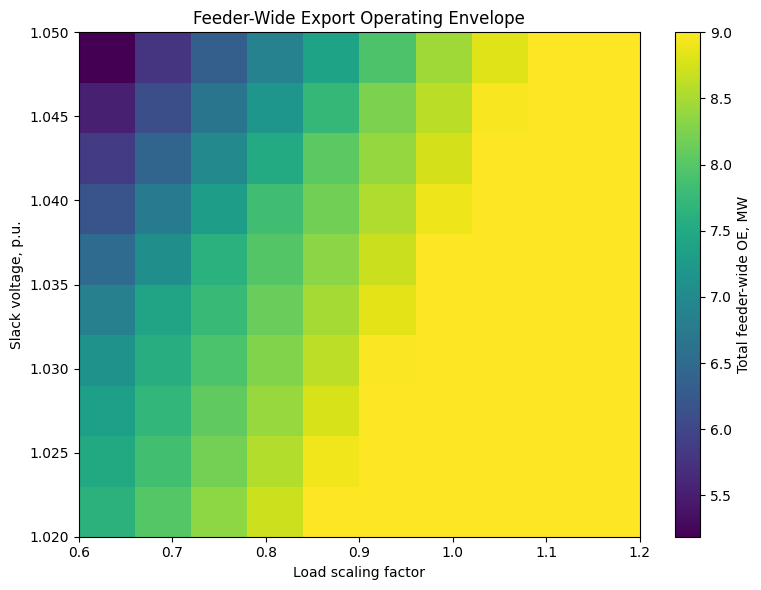

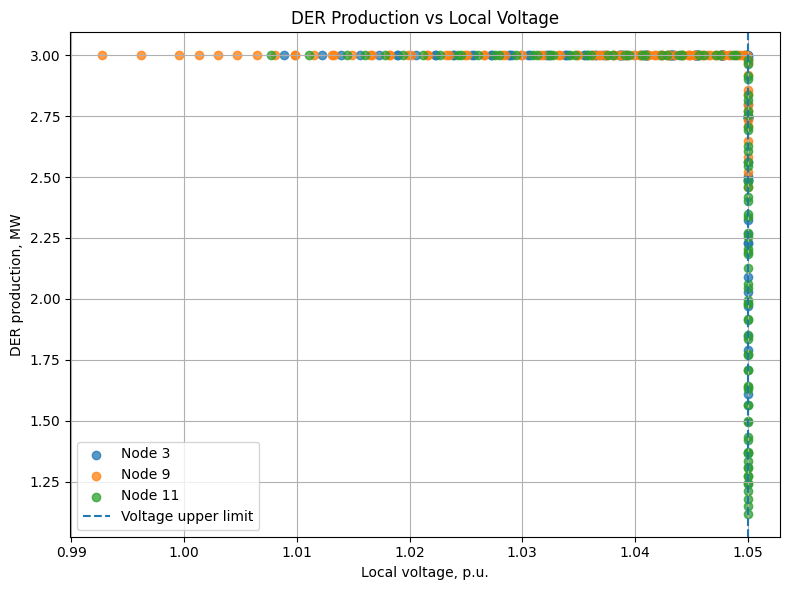

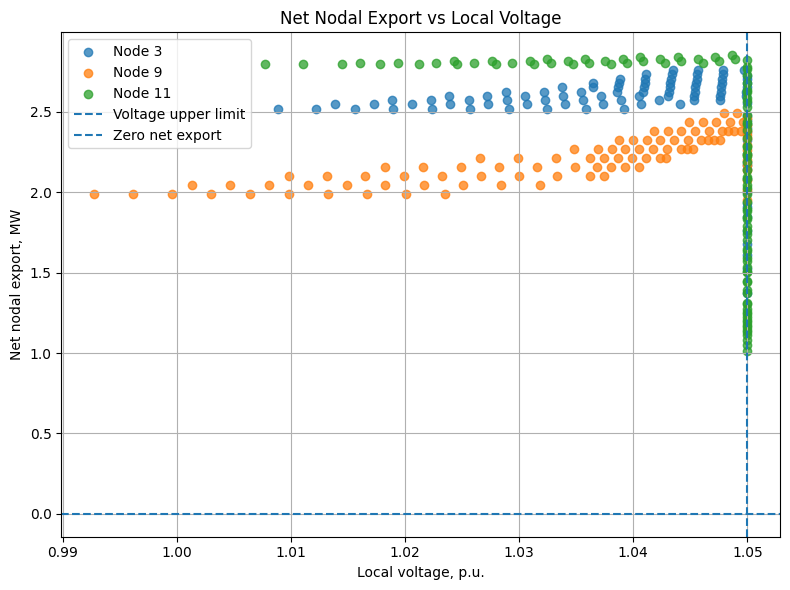

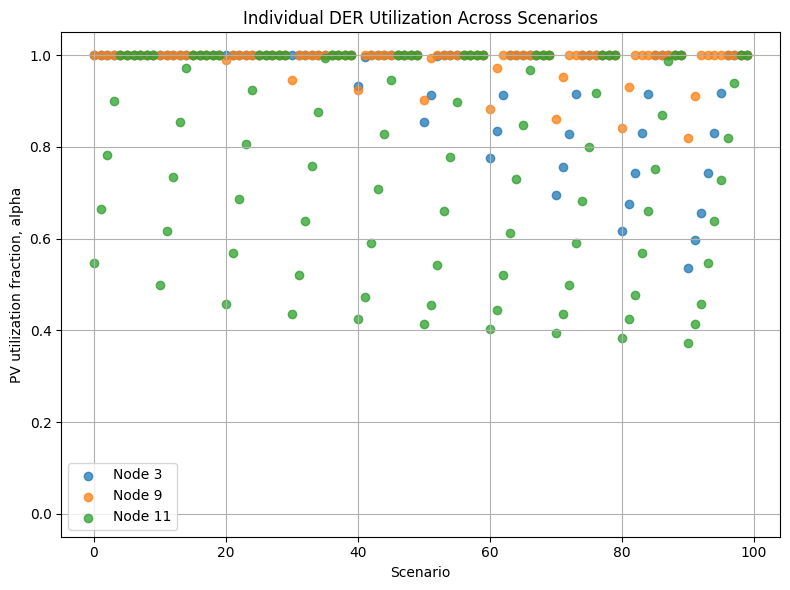

In [1]:
import os
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "results_feeder_wide"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DER_NODES = [3, 9, 11]

# Scenario grid for the full 10 x 10 study
SLACK_VOLTAGE_MIN = 1.02
SLACK_VOLTAGE_MAX = 1.05
N_SLACK_STEPS = 10

LOAD_FACTOR_MIN = 0.6
LOAD_FACTOR_MAX = 1.2
N_LOAD_STEPS = 10

# Thermal constraints remain disabled at this stage.
USE_THERMAL_CONSTRAINT = False

# Optional local voltage-based reactive power support.
# Keep False for the feeder-wide baseline unless a Q-control comparison is required.
USE_REACTIVE_SUPPORT = False
QMAX_FRAC = 0.25

print("Output directory:", OUTPUT_DIR)
print("Number of scenarios:", N_SLACK_STEPS * N_LOAD_STEPS)

N = 13
slack = 0

base_l_P = np.array([
    0, 0.2, 0, 0.4, 0.17, 0.23, 1.155,
    0, 0.17, 0.843, 0, 0.17, 0.128
])

base_l_Q = np.array([
    0, 0.116, 0, 0.29, 0.125, 0.132,
    0.66, 0, 0.151, 0.462, 0, 0.08, 0.086
])

v_min = 0.95
v_max = 1.05

r = np.array([
[0, 0.007547918, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0041, 0, 0.007239685, 0, 0.007547918, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004343811, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.003773959, 0, 0, 0.004322245, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00434686, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004343157, 0.01169764],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

x = np.array([
[0, 0.022173236, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0.0064, 0, 0.007336076, 0, 0.022173236, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.004401645, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0.011086618, 0, 0, 0.004433667, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0.002430473, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.004402952, 0.004490848],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

I_max = np.array([
[0, 3.0441, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1.4178, 0, 0.9591, 0, 3.0441, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 3.1275, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0.9591, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 3.0441, 3.1275, 0, 0.9591, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1.37193, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9591, 1.2927],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

A = np.array([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
])

edges = [(i, j) for i in range(N) for j in range(N) if A[i, j] == 1]

children = {i: [] for i in range(N)}
parent = {}
for i, j in edges:
    children[i].append(j)
    parent[j] = i

print("Number of feeder branches:", len(edges))

pv_capacity = np.zeros(N)
pv_capacity[3] = 3.0
pv_capacity[9] = 3.0
pv_capacity[11] = 3.0

def get_pv_available():
    """Full PV availability is assumed in this network-stress scenario grid."""
    pv_available = np.zeros(N)
    for j in DER_NODES:
        pv_available[j] = pv_capacity[j]
    return pv_available

def create_scenario_grid():
    slack_values = np.linspace(
        SLACK_VOLTAGE_MIN,
        SLACK_VOLTAGE_MAX,
        N_SLACK_STEPS,
    )
    load_values = np.linspace(
        LOAD_FACTOR_MIN,
        LOAD_FACTOR_MAX,
        N_LOAD_STEPS,
    )

    rows = []
    scenario = 0
    for slack_voltage_pu in slack_values:
        for load_factor in load_values:
            rows.append({
                "scenario": scenario,
                "slack_voltage_pu": float(slack_voltage_pu),
                "load_factor": float(load_factor),
            })
            scenario += 1

    return pd.DataFrame(rows)

scenario_df = create_scenario_grid()
scenario_df

def solve_feeder_wide_export_oe(
    l_P,
    l_Q,
    pv_available,
    slack_voltage_pu,
    use_reactive_support=False,
    qmax_frac=0.0,
    verbose=False,
):
    P = cp.Variable((N, N))
    Q = cp.Variable((N, N))
    v = cp.Variable(N)

    # Individual active-power production at every node.
    p_der = cp.Variable(N, nonneg=True)
    q_der = cp.Variable(N)

    constraints = [
        v[slack] == slack_voltage_pu ** 2,
        v >= v_min ** 2,
        v <= v_max ** 2,
    ]

    # DER availability bounds and zero generation at non-DER nodes.
    for j in range(N):
        if j in DER_NODES:
            constraints += [p_der[j] <= pv_available[j]]
        else:
            constraints += [
                p_der[j] == 0,
                q_der[j] == 0,
            ]

    # Optional voltage-based Q droop.
    if use_reactive_support:
        for j in DER_NODES:
            qmax_j = qmax_frac * pv_capacity[j]
            constraints += [
                q_der[j] == qmax_j * (
                    (v_max ** 2 + v_min ** 2 - 2.0 * v[j])
                    / (v_max ** 2 - v_min ** 2)
                )
            ]
    else:
        constraints += [q_der == 0]

    # Flows are zero on non-existing branches.
    edge_set = set(edges)
    for i in range(N):
        for j in range(N):
            if (i, j) not in edge_set:
                constraints += [
                    P[i, j] == 0,
                    Q[i, j] == 0,
                ]

    # Radial active/reactive power balances and linearized voltage drop.
    for j in range(1, N):
        i = parent[j]

        downstream_P = cp.sum([P[j, k] for k in children[j]])
        downstream_Q = cp.sum([Q[j, k] for k in children[j]])

        net_P = l_P[j] - p_der[j]
        net_Q = l_Q[j] - q_der[j]

        constraints += [
            P[i, j] == net_P + downstream_P,
            Q[i, j] == net_Q + downstream_Q,
            v[j] == v[i] - 2.0 * (
                r[i, j] * P[i, j]
                + x[i, j] * Q[i, j]
            ),
        ]

        if USE_THERMAL_CONSTRAINT:
            constraints += [
                cp.norm(cp.hstack([P[i, j], Q[i, j]]), 2)
                <= I_max[i, j]
            ]

    oe_total = cp.sum(p_der[DER_NODES])
    problem = cp.Problem(cp.Maximize(oe_total), constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=verbose)
    except Exception:
        problem.solve(solver=cp.SCS, verbose=verbose)

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        return {
            "status": problem.status,
            "OE_total_MW": np.nan,
            "p_der": np.full(N, np.nan),
            "q_der": np.full(N, np.nan),
            "voltage": np.full(N, np.nan),
        }

    voltage = np.sqrt(np.maximum(v.value, 0.0))

    return {
        "status": problem.status,
        "OE_total_MW": float(np.sum(p_der.value[DER_NODES])),
        "p_der": np.asarray(p_der.value, dtype=float),
        "q_der": np.asarray(q_der.value, dtype=float),
        "voltage": voltage,
    }

pv_available = get_pv_available()

scenario_rows = []
der_rows = []

for _, row in scenario_df.iterrows():
    scenario = int(row["scenario"])
    slack_voltage_pu = float(row["slack_voltage_pu"])
    load_factor = float(row["load_factor"])

    l_P_s = base_l_P * load_factor
    l_Q_s = base_l_Q * load_factor

    result = solve_feeder_wide_export_oe(
        l_P=l_P_s,
        l_Q=l_Q_s,
        pv_available=pv_available,
        slack_voltage_pu=slack_voltage_pu,
        use_reactive_support=USE_REACTIVE_SUPPORT,
        qmax_frac=QMAX_FRAC,
    )

    voltage = result["voltage"]
    p_der = result["p_der"]
    q_der = result["q_der"]

    scenario_rows.append({
        "scenario": scenario,
        "slack_voltage_pu": slack_voltage_pu,
        "load_factor": load_factor,
        "status": result["status"],
        "OE_total_MW": result["OE_total_MW"],
        "total_PV_available_MW": float(np.sum(pv_available[DER_NODES])),
        "max_voltage_pu": (
            np.nan if np.all(np.isnan(voltage)) else float(np.nanmax(voltage))
        ),
        "min_voltage_pu": (
            np.nan if np.all(np.isnan(voltage)) else float(np.nanmin(voltage))
        ),
    })

    for j in DER_NODES:
        production = p_der[j]
        available = pv_available[j]
        load = l_P_s[j]

        der_rows.append({
            "scenario": scenario,
            "slack_voltage_pu": slack_voltage_pu,
            "load_factor": load_factor,
            "status": result["status"],
            "DER_node": j,
            "PV_available_MW": available,
            "P_DER_MW": production,
            "alpha": (
                np.nan if available <= 0 or np.isnan(production)
                else production / available
            ),
            "local_load_MW": load,
            "net_nodal_export_MW": (
                np.nan if np.isnan(production)
                else production - load
            ),
            "local_voltage_pu": voltage[j],
            "Q_DER_MVAr": q_der[j],
        })

scenario_results_df = pd.DataFrame(scenario_rows)
der_results_df = pd.DataFrame(der_rows)

feasible_scenarios = scenario_results_df[
    scenario_results_df["status"].isin(["optimal", "optimal_inaccurate"])
].copy()

feasible_der = der_results_df[
    der_results_df["status"].isin(["optimal", "optimal_inaccurate"])
].copy()

scenario_results_df.head()

scenario_file = os.path.join(
    OUTPUT_DIR,
    "feeder_wide_OE_scenario_results.csv",
)
der_file = os.path.join(
    OUTPUT_DIR,
    "feeder_wide_OE_individual_DER_results.csv",
)
summary_file = os.path.join(
    OUTPUT_DIR,
    "feeder_wide_OE_summary.csv",
)

scenario_results_df.to_csv(scenario_file, index=False)
der_results_df.to_csv(der_file, index=False)

summary = pd.DataFrame({
    "number_of_scenarios": [len(scenario_results_df)],
    "optimal_cases": [len(feasible_scenarios)],
    "infeasible_cases": [
        len(scenario_results_df) - len(feasible_scenarios)
    ],
    "mean_total_OE_MW": [feasible_scenarios["OE_total_MW"].mean()],
    "min_total_OE_MW": [feasible_scenarios["OE_total_MW"].min()],
    "max_total_OE_MW": [feasible_scenarios["OE_total_MW"].max()],
    "mean_max_voltage_pu": [feasible_scenarios["max_voltage_pu"].mean()],
    "mean_min_voltage_pu": [feasible_scenarios["min_voltage_pu"].mean()],
})

summary.to_csv(summary_file, index=False)

print("Feeder-wide OE summary")
print("----------------------")
print(summary.to_string(index=False))

print("\nMean DER production by node")
print("---------------------------")
print(
    feasible_der.groupby("DER_node")[
        ["P_DER_MW", "alpha", "net_nodal_export_MW", "local_voltage_pu"]
    ].mean()
)

print("\nSaved files:")
print("-", scenario_file)
print("-", der_file)
print("-", summary_file)

pivot_oe = scenario_results_df.pivot(
    index="slack_voltage_pu",
    columns="load_factor",
    values="OE_total_MW",
)

plt.figure(figsize=(8, 6))
plt.imshow(
    pivot_oe,
    origin="lower",
    aspect="auto",
    extent=[
        LOAD_FACTOR_MIN,
        LOAD_FACTOR_MAX,
        SLACK_VOLTAGE_MIN,
        SLACK_VOLTAGE_MAX,
    ],
)
plt.colorbar(label="Total feeder-wide OE, MW")
plt.xlabel("Load scaling factor")
plt.ylabel("Slack voltage, p.u.")
plt.title("Feeder-Wide Export Operating Envelope")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "feeder_wide_OE_heatmap.png"),
    dpi=300,
)
plt.show()

plt.figure(figsize=(8, 6))

for j in DER_NODES:
    node_data = feasible_der[feasible_der["DER_node"] == j]
    plt.scatter(
        node_data["local_voltage_pu"],
        node_data["P_DER_MW"],
        alpha=0.75,
        label=f"Node {j}",
    )

plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
plt.xlabel("Local voltage, p.u.")
plt.ylabel("DER production, MW")
plt.title("DER Production vs Local Voltage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "DER_production_vs_local_voltage.png"),
    dpi=300,
)
plt.show()

plt.figure(figsize=(8, 6))

for j in DER_NODES:
    node_data = feasible_der[feasible_der["DER_node"] == j]
    plt.scatter(
        node_data["local_voltage_pu"],
        node_data["net_nodal_export_MW"],
        alpha=0.75,
        label=f"Node {j}",
    )

plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
plt.axhline(0.0, linestyle="--", label="Zero net export")
plt.xlabel("Local voltage, p.u.")
plt.ylabel("Net nodal export, MW")
plt.title("Net Nodal Export vs Local Voltage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "net_nodal_export_vs_local_voltage.png"),
    dpi=300,
)
plt.show()

plt.figure(figsize=(8, 6))

for j in DER_NODES:
    node_data = feasible_der[feasible_der["DER_node"] == j]
    plt.scatter(
        node_data["scenario"],
        node_data["alpha"],
        alpha=0.75,
        label=f"Node {j}",
    )

plt.xlabel("Scenario")
plt.ylabel("PV utilization fraction, alpha")
plt.title("Individual DER Utilization Across Scenarios")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "individual_DER_utilization.png"),
    dpi=300,
)
plt.show()

## Additional plots for DER-level analysis

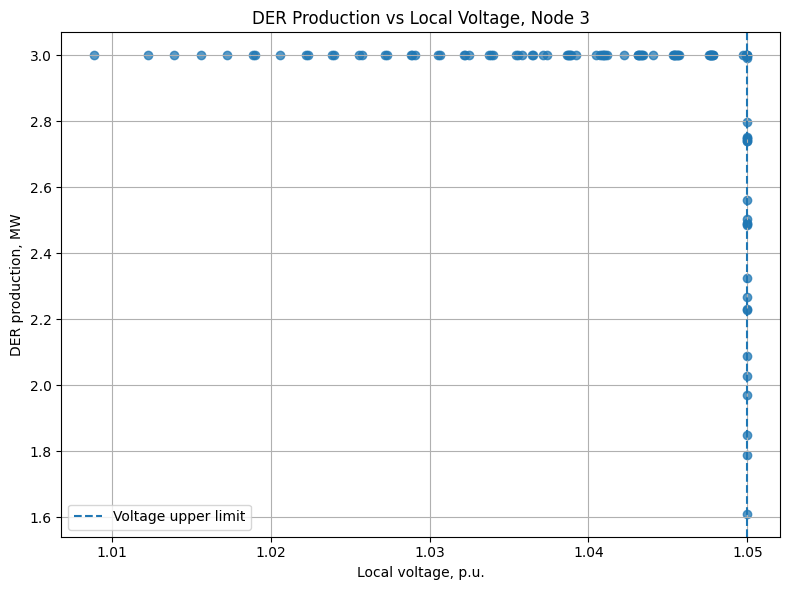

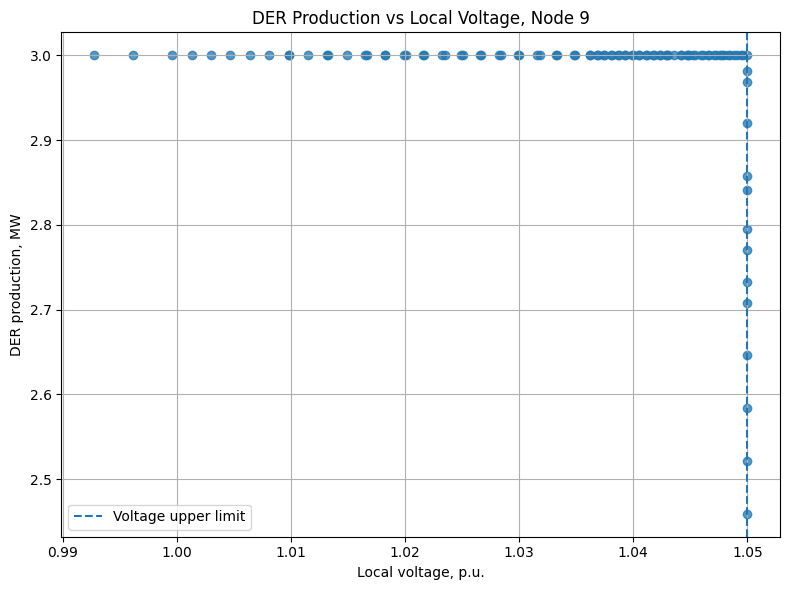

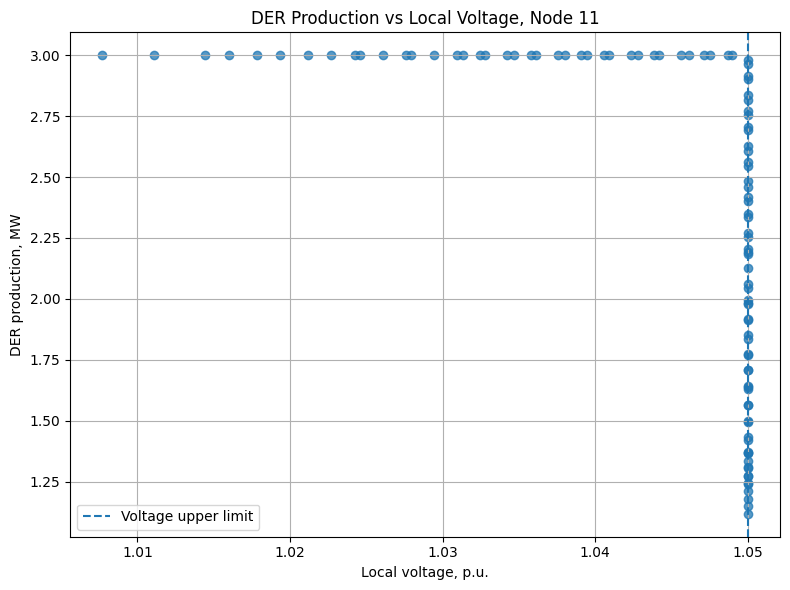

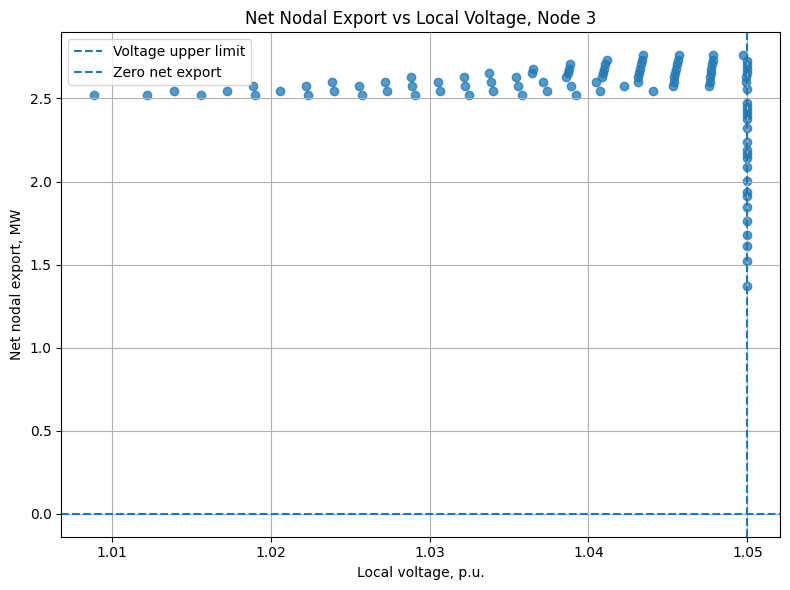

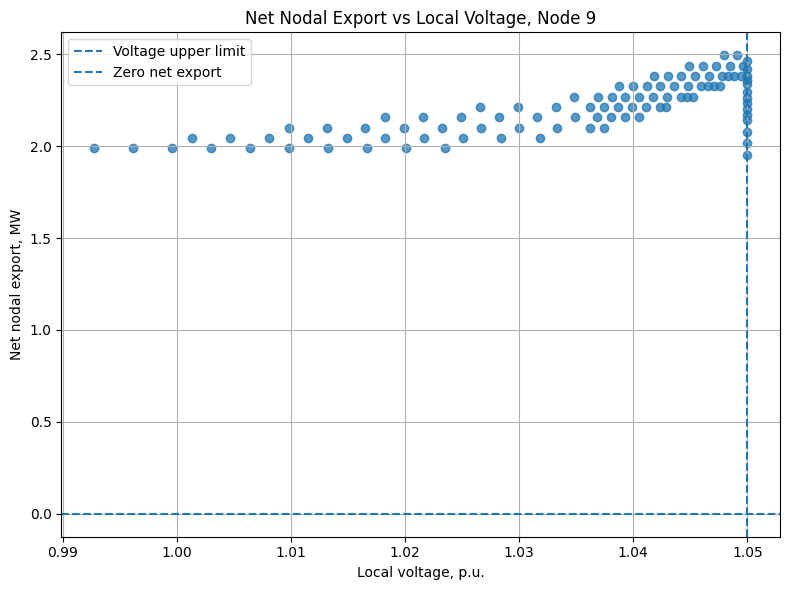

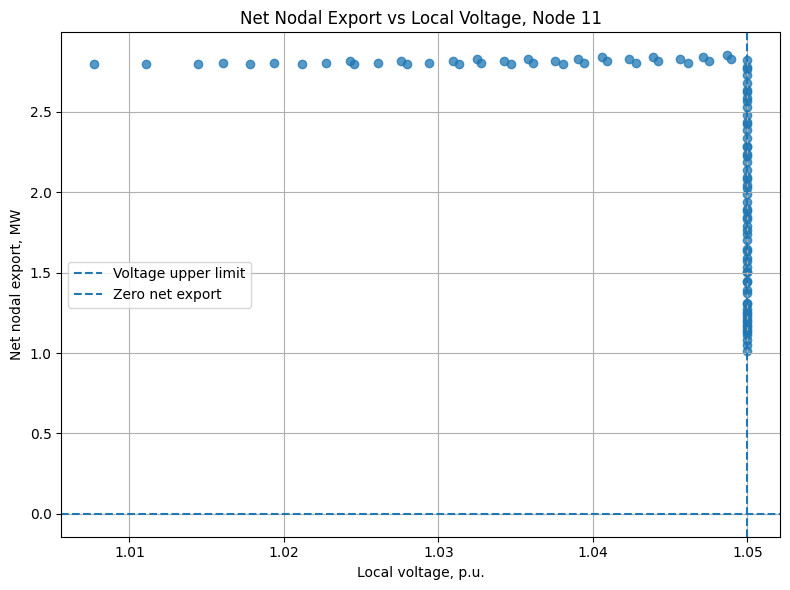

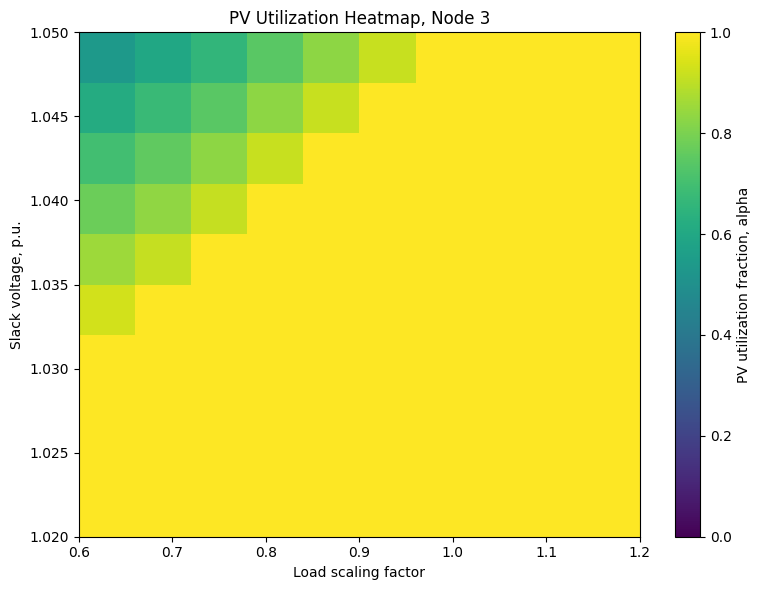

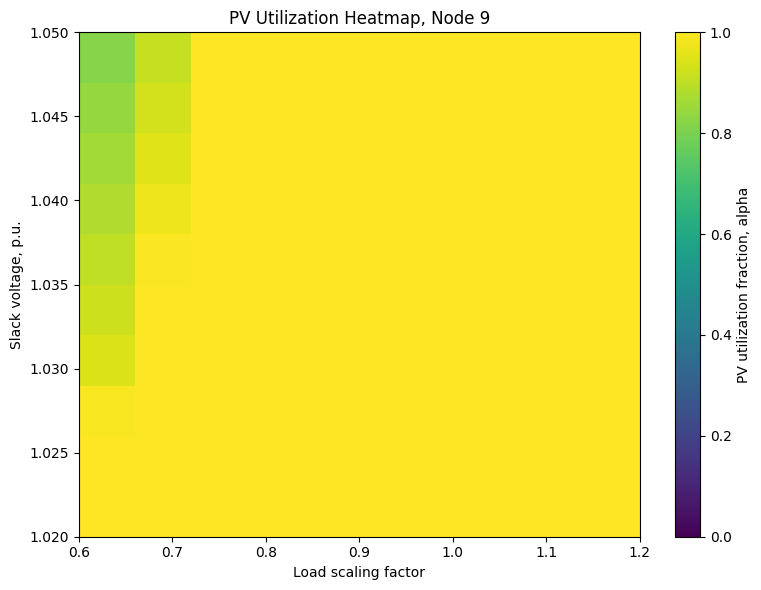

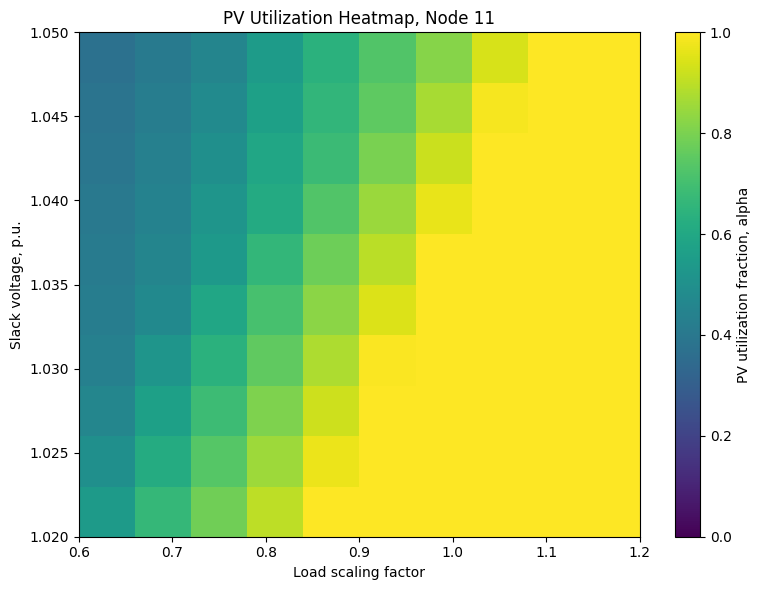

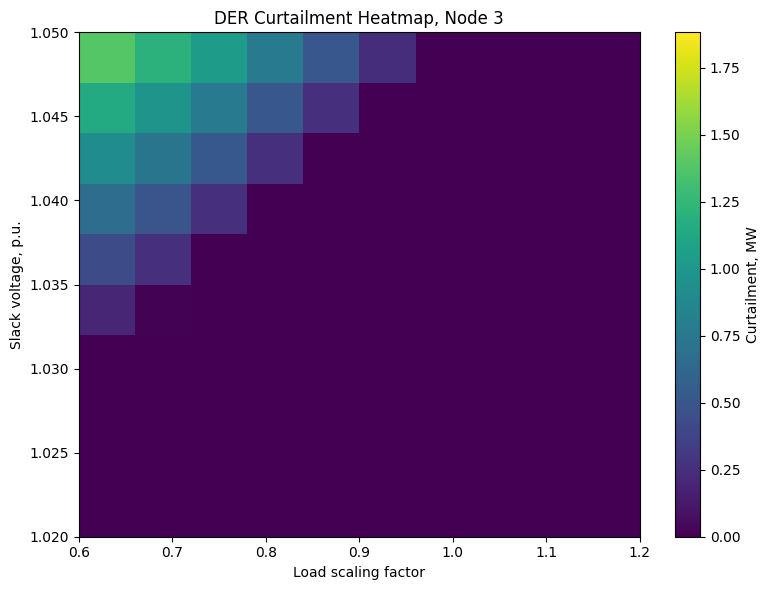

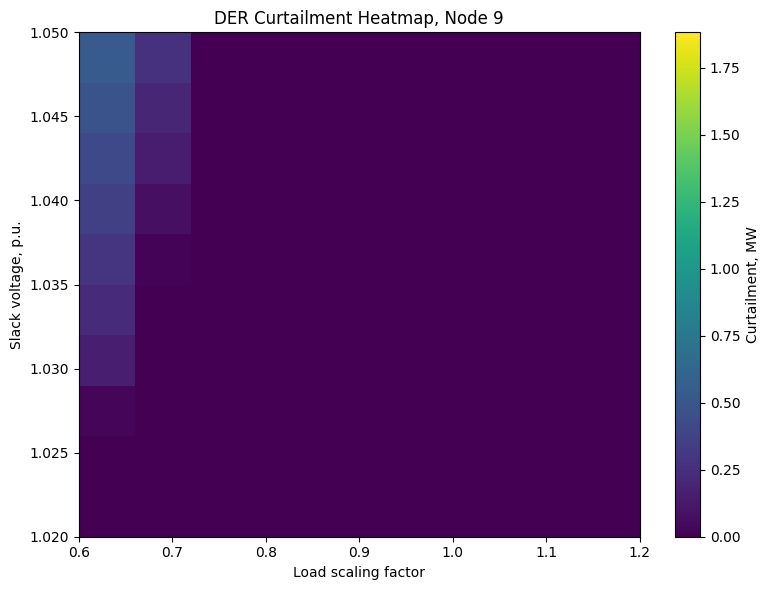

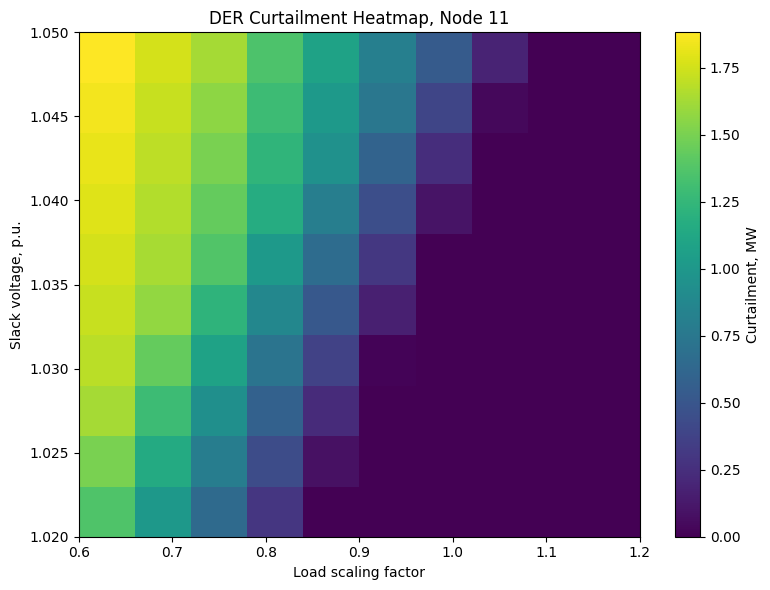

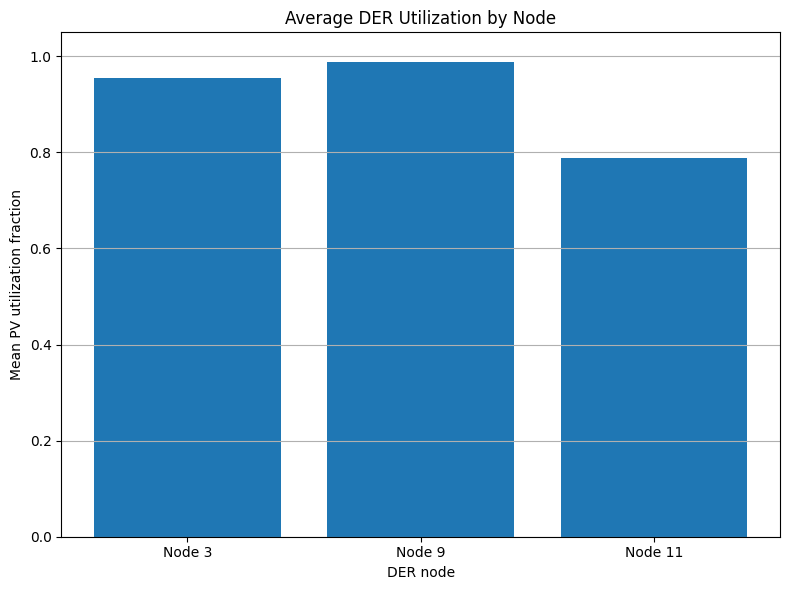

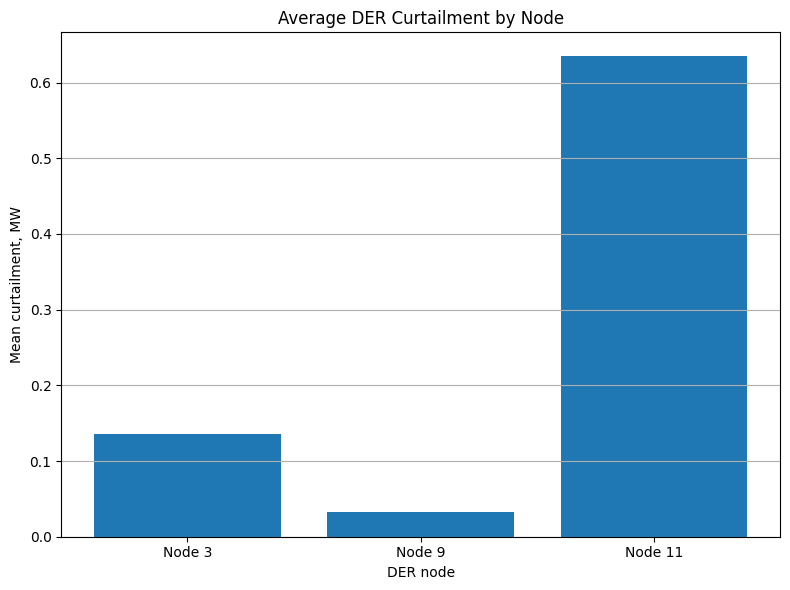

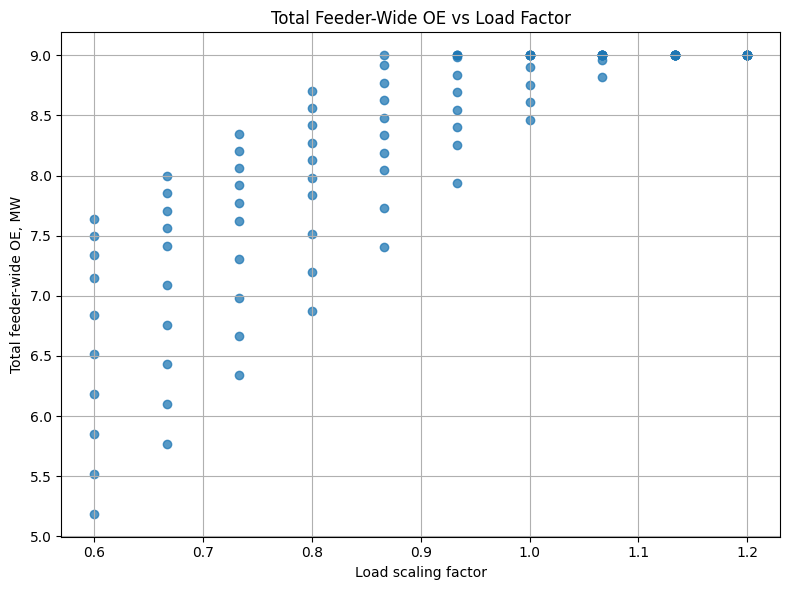

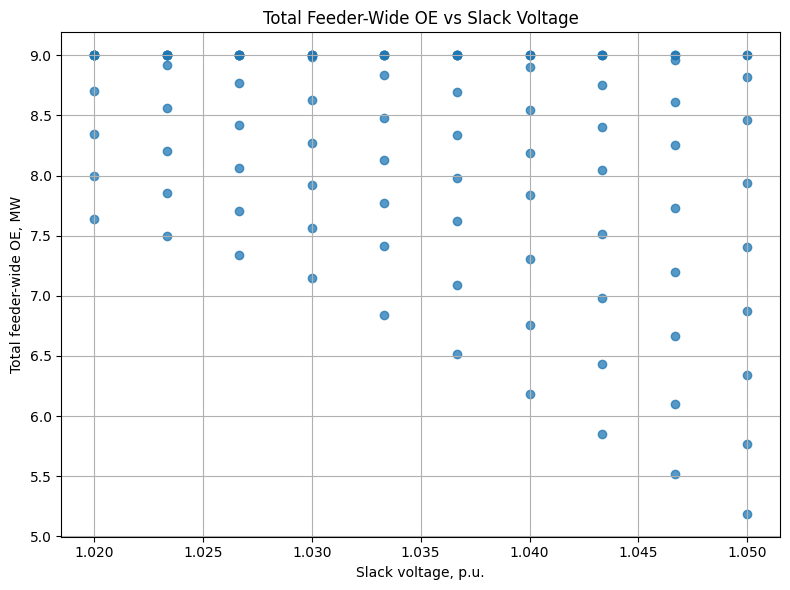


Additional plots saved in: results_feeder_wide


In [2]:
# Add curtailment columns if they are not already present.
der_results_df["curtailment_MW"] = (
    der_results_df["PV_available_MW"] - der_results_df["P_DER_MW"]
)

# ------------------------------------------------------------
# 1. DER production vs local voltage, one figure per DER
# ------------------------------------------------------------
for j in DER_NODES:
    node_data = feasible_der[feasible_der["DER_node"] == j]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        node_data["local_voltage_pu"],
        node_data["P_DER_MW"],
        alpha=0.75,
    )
    plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
    plt.xlabel("Local voltage, p.u.")
    plt.ylabel("DER production, MW")
    plt.title(f"DER Production vs Local Voltage, Node {j}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"DER_production_vs_local_voltage_node_{j}.png"
        ),
        dpi=300,
    )
    plt.show()

# ------------------------------------------------------------
# 2. Net nodal export vs local voltage, one figure per DER
# ------------------------------------------------------------
for j in DER_NODES:
    node_data = feasible_der[feasible_der["DER_node"] == j]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        node_data["local_voltage_pu"],
        node_data["net_nodal_export_MW"],
        alpha=0.75,
    )
    plt.axvline(v_max, linestyle="--", label="Voltage upper limit")
    plt.axhline(0.0, linestyle="--", label="Zero net export")
    plt.xlabel("Local voltage, p.u.")
    plt.ylabel("Net nodal export, MW")
    plt.title(f"Net Nodal Export vs Local Voltage, Node {j}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"net_nodal_export_vs_local_voltage_node_{j}.png"
        ),
        dpi=300,
    )
    plt.show()

# ------------------------------------------------------------
# 3. PV utilization heatmap for each DER
# ------------------------------------------------------------
for j in DER_NODES:
    node_data = der_results_df[der_results_df["DER_node"] == j]

    pivot_alpha = node_data.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="alpha",
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(
        pivot_alpha,
        origin="lower",
        aspect="auto",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
        vmin=0.0,
        vmax=1.0,
    )
    plt.colorbar(label="PV utilization fraction, alpha")
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"PV Utilization Heatmap, Node {j}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"PV_utilization_heatmap_node_{j}.png"
        ),
        dpi=300,
    )
    plt.show()

# ------------------------------------------------------------
# 4. Curtailment heatmap for each DER
# ------------------------------------------------------------
for j in DER_NODES:
    node_data = der_results_df[
        (der_results_df["DER_node"] == j)
        & (
            der_results_df["status"].isin(
                ["optimal", "optimal_inaccurate"]
            )
        )
    ].copy()

    pivot_curtailment = node_data.pivot(
        index="slack_voltage_pu",
        columns="load_factor",
        values="curtailment_MW",
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(
        pivot_curtailment,
        origin="lower",
        aspect="auto",
        extent=[
            LOAD_FACTOR_MIN,
            LOAD_FACTOR_MAX,
            SLACK_VOLTAGE_MIN,
            SLACK_VOLTAGE_MAX,
        ],
        vmin=0.0,
        vmax=float(
            der_results_df["curtailment_MW"].max()
        ),
    )
    plt.colorbar(label="Curtailment, MW")
    plt.xlabel("Load scaling factor")
    plt.ylabel("Slack voltage, p.u.")
    plt.title(f"DER Curtailment Heatmap, Node {j}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"DER_curtailment_heatmap_node_{j}.png"
        ),
        dpi=300,
    )
    plt.show()

# ------------------------------------------------------------
# 5. Average DER utilization comparison
# ------------------------------------------------------------
mean_utilization = (
    feasible_der.groupby("DER_node")["alpha"]
    .mean()
    .reindex(DER_NODES)
)

plt.figure(figsize=(8, 6))
plt.bar(
    [f"Node {j}" for j in DER_NODES],
    mean_utilization.values,
)
plt.ylim(0.0, 1.05)
plt.xlabel("DER node")
plt.ylabel("Mean PV utilization fraction")
plt.title("Average DER Utilization by Node")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "average_DER_utilization_by_node.png"
    ),
    dpi=300,
)
plt.show()

# ------------------------------------------------------------
# 6. Average curtailment comparison
# ------------------------------------------------------------
mean_curtailment = (
    feasible_der.assign(
        curtailment_MW=(
            feasible_der["PV_available_MW"]
            - feasible_der["P_DER_MW"]
        )
    )
    .groupby("DER_node")["curtailment_MW"]
    .mean()
    .reindex(DER_NODES)
)

plt.figure(figsize=(8, 6))
plt.bar(
    [f"Node {j}" for j in DER_NODES],
    mean_curtailment.values,
)
plt.xlabel("DER node")
plt.ylabel("Mean curtailment, MW")
plt.title("Average DER Curtailment by Node")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "average_DER_curtailment_by_node.png"
    ),
    dpi=300,
)
plt.show()

# ------------------------------------------------------------
# 7. Total OE vs load factor
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    feasible_scenarios["load_factor"],
    feasible_scenarios["OE_total_MW"],
    alpha=0.75,
)
plt.xlabel("Load scaling factor")
plt.ylabel("Total feeder-wide OE, MW")
plt.title("Total Feeder-Wide OE vs Load Factor")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "total_OE_vs_load_factor.png"
    ),
    dpi=300,
)
plt.show()

# ------------------------------------------------------------
# 8. Total OE vs slack voltage
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(
    feasible_scenarios["slack_voltage_pu"],
    feasible_scenarios["OE_total_MW"],
    alpha=0.75,
)
plt.xlabel("Slack voltage, p.u.")
plt.ylabel("Total feeder-wide OE, MW")
plt.title("Total Feeder-Wide OE vs Slack Voltage")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "total_OE_vs_slack_voltage.png"
    ),
    dpi=300,
)
plt.show()

print("\nAdditional plots saved in:", OUTPUT_DIR)

## OE vs local voltage vs local demand

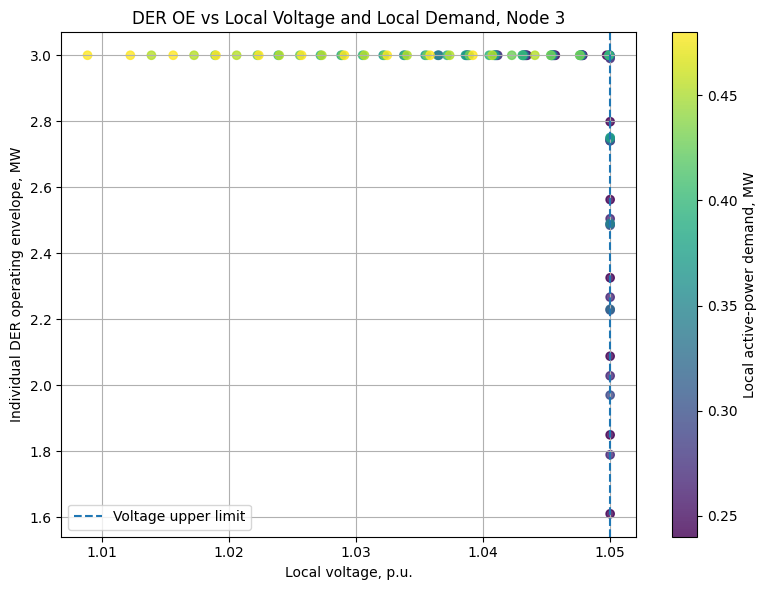

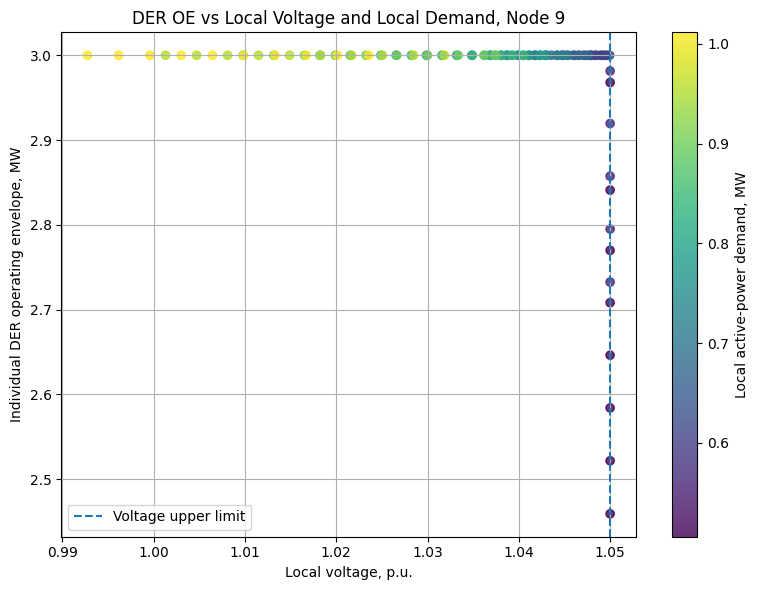

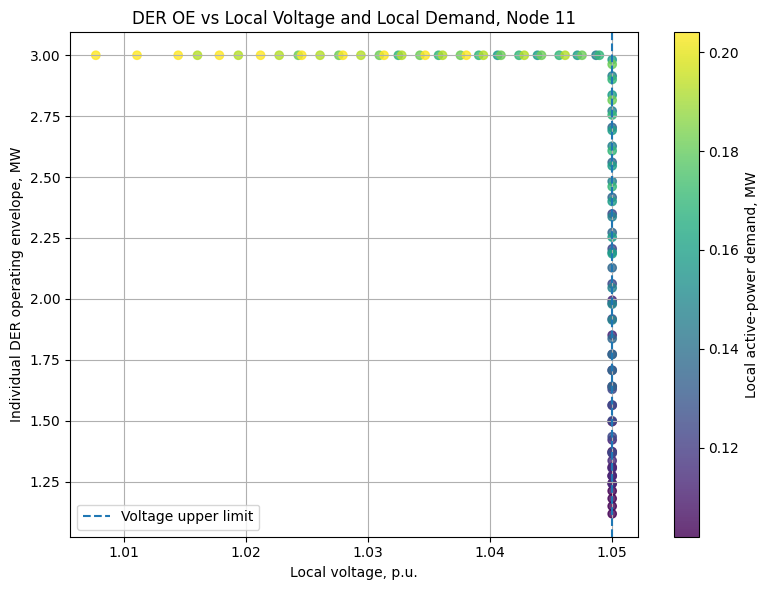

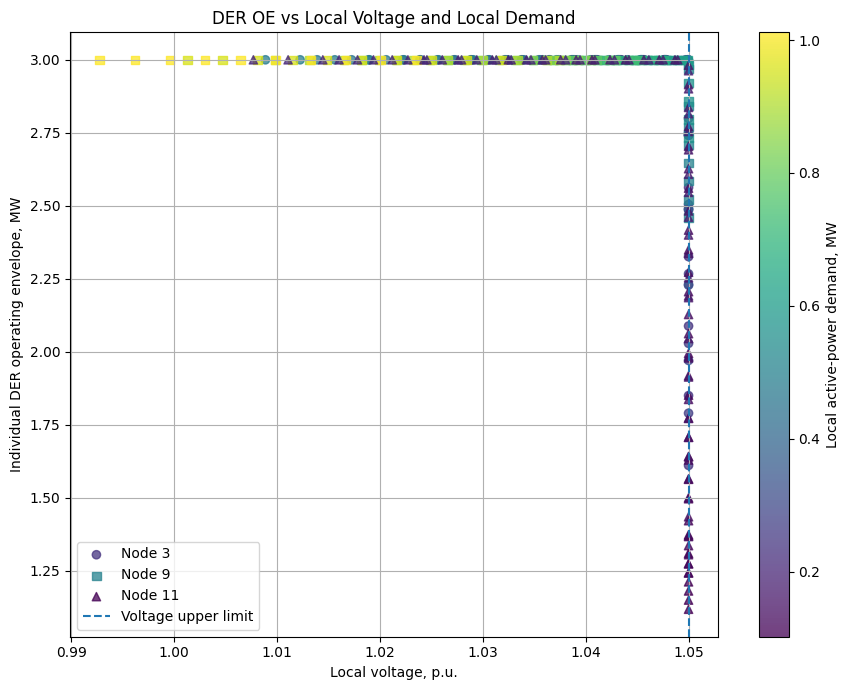

In [3]:
# Individual DER OE is represented by the optimized P_DER_MW.
# Local demand is represented by the colour scale.

for j in DER_NODES:
    node_data = feasible_der[
        feasible_der["DER_node"] == j
    ].copy()

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        node_data["local_voltage_pu"],
        node_data["P_DER_MW"],
        c=node_data["local_load_MW"],
        alpha=0.80,
    )

    plt.axvline(
        v_max,
        linestyle="--",
        label="Voltage upper limit",
    )

    plt.colorbar(
        scatter,
        label="Local active-power demand, MW",
    )

    plt.xlabel("Local voltage, p.u.")
    plt.ylabel("Individual DER operating envelope, MW")
    plt.title(
        f"DER OE vs Local Voltage and Local Demand, Node {j}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"DER_OE_vs_local_voltage_local_demand_node_{j}.png",
        ),
        dpi=300,
    )

    plt.show()


# Combined plot for all DER nodes.
plt.figure(figsize=(9, 7))

markers = {
    DER_NODES[0]: "o",
    DER_NODES[1]: "s",
    DER_NODES[2]: "^",
}

combined_scatter = None

for j in DER_NODES:
    node_data = feasible_der[
        feasible_der["DER_node"] == j
    ].copy()

    combined_scatter = plt.scatter(
        node_data["local_voltage_pu"],
        node_data["P_DER_MW"],
        c=node_data["local_load_MW"],
        marker=markers[j],
        alpha=0.75,
        label=f"Node {j}",
        vmin=feasible_der["local_load_MW"].min(),
        vmax=feasible_der["local_load_MW"].max(),
    )

plt.axvline(
    v_max,
    linestyle="--",
    label="Voltage upper limit",
)

plt.colorbar(
    combined_scatter,
    label="Local active-power demand, MW",
)

plt.xlabel("Local voltage, p.u.")
plt.ylabel("Individual DER operating envelope, MW")
plt.title("DER OE vs Local Voltage and Local Demand")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "DER_OE_vs_local_voltage_local_demand_all_nodes.png",
    ),
    dpi=300,
)

plt.show()